In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

In [2]:
params = {'legend.fontsize': 'large',
          'axes.labelsize': 'large',
          'axes.titlesize': 'large',
          'xtick.labelsize': 'large',
          'ytick.labelsize': 'large',
          'figure.facecolor': 'w',
          'xtick.top': True,
          'ytick.right': True,
          'xtick.direction': 'in',
          'ytick.direction': 'in',
         }
plt.rcParams.update(params)

In [3]:
cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/sv1_perexp_lrg.fits'))
cat['EFFTIME_ELG'] = 8.60 * cat['TSNR2_ELG']
cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Apply LRG mask
mask = cat['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove QSO targets
mask = cat['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# # Require a minimum depth
# min_depth = 500.
# mask = cat['EFFTIME_LRG']>min_depth
# print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
# cat = cat[mask]

# # Julien's bad fibers list + my list of worst-performing fibers; bad_fibers-fugu.ipynb
# # bad_fibers = np.loadtxt('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/misc/bad_fibers_20211117.txt', dtype=int)
# bad_fibers = np.loadtxt('/Users/rongpu/Documents/Data/desi_data/fugu/misc/bad_fibers_20211117.txt', dtype=int)
# print(len(bad_fibers))
# mask_bad = np.in1d(cat['FIBER'], bad_fibers)
# print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
# cat = cat[~mask_bad]
# print(len(cat), len(np.unique(cat['TARGETID'])))

FIBERSTATUS 464751 107007 0.18715435551404616
No data 464751 0 0.0
LRG mask 417693 47058 0.10125422000167832
Remove QSO targets 403772 13921 0.03332830571735701


In [4]:
cat_1x = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/sv1_1x_depth_lrg.fits'))
cat_1x['EFFTIME_ELG'] = 8.60 * cat_1x['TSNR2_ELG']
cat_1x['EFFTIME_LRG'] = 12.15 * cat_1x['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat_1x['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# Remove "no data" fibers
mask = cat_1x['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# Apply LRG mask
mask = cat_1x['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# Remove QSO targets
mask = cat_1x['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# # Require a minimum depth
# min_depth = 500.
# mask = cat_1x['EFFTIME_LRG']>min_depth
# print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
# cat_1x = cat_1x[mask]

# # Julien's bad fibers list + my list of worst-performing fibers; bad_fibers-fugu.ipynb
# # bad_fibers = np.loadtxt('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/misc/bad_fibers_20211117.txt', dtype=int)
# bad_fibers = np.loadtxt('/Users/rongpu/Documents/Data/desi_data/fugu/misc/bad_fibers_20211117.txt', dtype=int)
# print(len(bad_fibers))
# mask_bad = np.in1d(cat_1x['FIBER'], bad_fibers)
# print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
# cat_1x = cat_1x[~mask_bad]
# print(len(cat_1x), len(np.unique(cat_1x['TARGETID'])))

FIBERSTATUS 27110 4943 0.15421333416528873
No data 27110 0 0.0
LRG mask 25008 2102 0.07753596458871265
Remove QSO targets 24493 515 0.020593410108765194


In [5]:
columns = list(np.intersect1d(cat.colnames, cat_1x.colnames))
cat = cat[columns]
cat_1x = cat_1x[columns]

cat = vstack([cat, cat_1x])

In [6]:
deep = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/sv1_cumulative_lrg.fits'))
deep['EFFTIME_ELG'] = 8.60 * deep['TSNR2_ELG']
deep['EFFTIME_LRG'] = 12.15 * deep['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = deep['COADD_FIBERSTATUS']==0
print('COADD_FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

mask = deep['ZWARN']==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Apply LRG mask
mask = deep['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Remove QSO targets
mask = deep['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Require a minimum depth
min_depth = 3000.
mask = deep['EFFTIME_LRG']>min_depth
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
deep = deep[mask]

# # Julien's bad fibers list + my list of worst-performing fibers; bad_fibers-fugu.ipynb
# # bad_fibers = np.loadtxt('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/misc/bad_fibers_20211117.txt', dtype=int)
# bad_fibers = np.loadtxt('/Users/rongpu/Documents/Data/desi_data/fugu/misc/bad_fibers_20211117.txt', dtype=int)
# print(len(bad_fibers))
# mask_bad = np.in1d(deep['FIBER'], bad_fibers)
# print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
# deep = deep[~mask_bad]
# print(len(deep), len(np.unique(deep['TARGETID'])))

# Remove duplidates keeping the higher EFFTIME objects
deep.sort('EFFTIME_LRG', reverse=True)
_, idx_keep = np.unique(deep['TARGETID'], return_index=True)
deep = deep[idx_keep]
print(len(deep), len(np.unique(deep['TARGETID'])))

mask_star = (deep['SPECTYPE']=='STAR') | (deep['Z']<0.0003)
print('Remove stars', np.sum(mask_star), np.sum(~mask_star), np.sum(mask_star)/len(mask_star))
deep = deep[~mask_star]
print(len(deep))

deep_columns_old = ['TARGETID', 'Z', 'ZERR', 'ZWARN', 'SPECTYPE', 'DELTACHI2', 'EFFTIME_LRG', 'EFFTIME_ELG']
deep_columns_new = ['TARGETID', 'Z_deep', 'ZERR_deep', 'ZWARN_deep', 'SPECTYPE_deep', 'DELTACHI2_deep', 'EFFTIME_LRG_deep', 'EFFTIME_ELG_deep']
deep.rename_columns(deep_columns_old, deep_columns_new)

cat = join(cat, deep[deep_columns_new], keys='TARGETID')

COADD_FIBERSTATUS 46319 8916 0.16141938987960533
No data 45437 882 0.01904186187093849
LRG mask 41340 4097 0.09016880515879129
Remove QSO targets 39668 1672 0.040445089501693274
Min depth 30425 9243 0.7669910255117475
30377 30377
Remove stars 259 30118 0.008526187576126675
30118


In [7]:
main = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/main_cumulative_lrg.fits'))
main['EFFTIME_ELG'] = 8.60 * main['TSNR2_ELG']
main['EFFTIME_LRG'] = 12.15 * main['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = main['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]

# Remove "no data" fibers
mask = main['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]

# Apply LRG mask
mask = main['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]

# Remove QSO targets
mask = main['DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
main = main[mask]

# # Require a minimum depth
# min_depth = 500.
# mask = main['EFFTIME_LRG']>min_depth
# print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
# main = main[mask]

# # Julien's bad fibers list + my list of worst-performing fibers; bad_fibers-fugu.ipynb
# # bad_fibers = np.loadtxt('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/misc/bad_fibers_20211117.txt', dtype=int)
# bad_fibers = np.loadtxt('/Users/rongpu/Documents/Data/desi_data/fugu/misc/bad_fibers_20211117.txt', dtype=int)
# print(len(bad_fibers))
# mask_bad = np.in1d(main['FIBER'], bad_fibers)
# print('Bad fibers', np.sum(~mask_bad), np.sum(mask_bad), np.sum(mask_bad)/len(mask_bad))
# main = main[~mask_bad]
# print(len(main), len(np.unique(main['TARGETID'])))

mask_star = (main['SPECTYPE']=='STAR') | (main['Z']<0.0003)
print('Remove stars', np.sum(mask_star), np.sum(~mask_star), np.sum(mask_star)/len(mask_star))
main = main[~mask_star]
print(len(main))

FIBERSTATUS 338266 7165 0.020742203218587794
No data 338265 1 2.9562533627382e-06
LRG mask 304337 33928 0.1003000606033731
Remove QSO targets 299639 4698 0.015436834824553046
Remove stars 1437 298202 0.004795770910996232
298202


In [8]:
mask = cat['EFFTIME_LRG']>800
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
cat = cat[mask]
print(len(cat))

Min depth 65432 308499 0.17498415483070406
65432


In [9]:
mask = main['EFFTIME_LRG']>800
print('Min depth', np.sum(mask), np.sum(~mask), np.sum(mask)/len(mask))
main = main[mask]
print(len(main))

Min depth 286892 11310 0.962072688982636
286892


In [10]:
cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']) - 1.211 * cat['EBV']
main['zfibermag'] = 22.5 - 2.5*np.log10(main['FIBERFLUX_Z']) - 1.211 * main['EBV']

---------

In [11]:
# Catastrophic redshift failures
zdiff_threshold = 0.0033
mask_fail = np.abs((cat['Z'] - cat['Z_deep'])/(1 + cat['Z_deep'])) > zdiff_threshold
# Also reject objects with ZWARN!=0 or z>1.5 in the deep coadds
mask_deep_fail = (cat['ZWARN_deep']!=0) | (cat['Z_deep']>1.6)
# mask_deep_fail = (cat['ZWARN_deep']!=0) | (cat['Z_deep']>1.5) | (cat['DELTACHI2_deep']<25)
mask_fail |= mask_deep_fail
print('All SV LRGs:')
print('Catastrophic failure rate: {:.2f}% ({}/{})'.format(100*np.sum(mask_fail)/len(mask_fail), np.sum(mask_fail), len(mask_fail)))
print()

mask = cat['main_lrg'].copy()
print('Main LRGs in SV:')
print('Catastrophic failure rate: {:.2f}% ({}/{})'.format(100*np.sum(mask_fail & mask)/np.sum(mask), np.sum(mask_fail & mask), np.sum(mask)))

All SV LRGs:
Catastrophic failure rate: 2.88% (1886/65432)

Main LRGs in SV:
Catastrophic failure rate: 0.73% (134/18331)


In [12]:
# DELTACHI2 cut
q0 = cat['ZWARN']==0
q0 &= (cat['Z']<1.5)
q0 &= cat['DELTACHI2']>15

# Redshift quality: custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*cat['Z']))
q = ((cat['DELTACHI2']>d) & (cat['DELTACHI2']>10)) | (cat['DELTACHI2']>30)
q &= cat['Z']<1.5
q &= cat['ZWARN']<1.5

# Custom DELTACHI2 vs zfiber cut
q1 = cat['DELTACHI2'] > 10**(-(cat['zfibermag']-20)*0.4*2 + 2.17)
q1 |= cat['DELTACHI2'] > 10**(-(cat['zfibermag']-20)*0.4 + 2.1)
q1 &= cat['ZWARN']==0
q1 &= cat['Z']<1.5

In [13]:
print('########### DELTACHI2 cut ###########')
print('SV LRGs:')
print('Removed fraction: {:.2f}%'.format(100*np.sum(~q0)/len(q0)))
print('Catastrophic failure rate of removed objects: {:.2f}% ({}/{})'.format(100*np.sum((~q0) & mask_fail)/np.sum(~q0), np.sum((~q0) & mask_fail), np.sum(~q0)))
print('Catastrophic failure rate of remaining objects: {:.2f}% ({}/{})'.format(100*np.sum((q0) & mask_fail)/np.sum(q0), np.sum(q0 & mask_fail), np.sum(q0)))
print()

mask = cat['main_lrg'].copy()
print('Main LRGs in SV:')
print('Removed fraction: {:.2f}%'.format(100*np.sum(mask & (~q0))/np.sum(mask)))
print('Catastrophic failure rate of removed objects: {:.2f}% ({}/{})'.format(100*np.sum(mask & (~q0) & mask_fail)/np.sum(mask & (~q0)), np.sum(mask & (~q0) & mask_fail), np.sum(mask & (~q0))))
print('Catastrophic failure rate of remaining objects: {:.2f}% ({}/{})'.format(100*np.sum(mask & q0 & mask_fail)/np.sum(mask & q0), np.sum(mask & q0 & mask_fail), np.sum(mask & q0)))

########### DELTACHI2 cut ###########
SV LRGs:
Removed fraction: 6.79%
Catastrophic failure rate of removed objects: 37.48% (1666/4445)
Catastrophic failure rate of remaining objects: 0.36% (220/60987)

Main LRGs in SV:
Removed fraction: 1.18%
Catastrophic failure rate of removed objects: 45.37% (98/216)
Catastrophic failure rate of remaining objects: 0.20% (36/18115)


In [14]:
print('########### DELTACHI2 vs redshift cut ###########')
print('SV LRGs:')
print('Removed fraction: {:.2f}%'.format(100*np.sum(~q)/len(q)))
print('Catastrophic failure rate of removed objects: {:.2f}% ({}/{})'.format(100*np.sum((~q) & mask_fail)/np.sum(~q), np.sum((~q) & mask_fail), np.sum(~q)))
print('Catastrophic failure rate of remaining objects: {:.2f}% ({}/{})'.format(100*np.sum((q) & mask_fail)/np.sum(q), np.sum(q & mask_fail), np.sum(q)))
print()

mask = cat['main_lrg'].copy()
print('Main LRGs in SV:')
print('Removed fraction: {:.2f}%'.format(100*np.sum(mask & (~q))/np.sum(mask)))
print('Catastrophic failure rate of removed objects: {:.2f}% ({}/{})'.format(100*np.sum(mask & (~q) & mask_fail)/np.sum(mask & (~q)), np.sum(mask & (~q) & mask_fail), np.sum(mask & (~q))))
print('Catastrophic failure rate of remaining objects: {:.2f}% ({}/{})'.format(100*np.sum(mask & q & mask_fail)/np.sum(mask & q), np.sum(mask & q & mask_fail), np.sum(mask & q)))

########### DELTACHI2 vs redshift cut ###########
SV LRGs:
Removed fraction: 5.12%
Catastrophic failure rate of removed objects: 48.63% (1630/3352)
Catastrophic failure rate of remaining objects: 0.41% (256/62080)

Main LRGs in SV:
Removed fraction: 0.89%
Catastrophic failure rate of removed objects: 57.93% (95/164)
Catastrophic failure rate of remaining objects: 0.21% (39/18167)


In [15]:
print('########### DELTACHI2 vs zfiber cut ###########')
print('SV LRGs:')
print('Removed fraction: {:.2f}%'.format(100*np.sum(~q1)/len(q1)))
print('Catastrophic failure rate of removed objects: {:.2f}% ({}/{})'.format(100*np.sum((~q1) & mask_fail)/np.sum(~q1), np.sum((~q1) & mask_fail), np.sum(~q1)))
print('Catastrophic failure rate of remaining objects: {:.2f}% ({}/{})'.format(100*np.sum((q1) & mask_fail)/np.sum(q1), np.sum(q1 & mask_fail), np.sum(q1)))
print()

mask = cat['main_lrg'].copy()
print('Main LRGs in SV:')
print('Removed fraction: {:.2f}%'.format(100*np.sum(mask & (~q1))/np.sum(mask)))
print('Catastrophic failure rate of removed objects: {:.2f}% ({}/{})'.format(100*np.sum(mask & (~q1) & mask_fail)/np.sum(mask & (~q1)), np.sum(mask & (~q1) & mask_fail), np.sum(mask & (~q1))))
print('Catastrophic failure rate of remaining objects: {:.2f}% ({}/{})'.format(100*np.sum(mask & q1 & mask_fail)/np.sum(mask & q1), np.sum(mask & q1 & mask_fail), np.sum(mask & q1)))

########### DELTACHI2 vs zfiber cut ###########
SV LRGs:
Removed fraction: 4.64%
Catastrophic failure rate of removed objects: 49.67% (1508/3036)
Catastrophic failure rate of remaining objects: 0.61% (378/62396)

Main LRGs in SV:
Removed fraction: 0.99%
Catastrophic failure rate of removed objects: 54.14% (98/181)
Catastrophic failure rate of remaining objects: 0.20% (36/18150)


In [16]:
q2 = q & q1

print('########### DELTACHI2 vs redshift cut + DELTACHI2 vs zfiber cut ###########')
print('SV LRGs:')
print('Removed fraction: {:.2f}%'.format(100*np.sum(~q2)/len(q2)))
print('Catastrophic failure rate of removed objects: {:.2f}% ({}/{})'.format(100*np.sum((~q2) & mask_fail)/np.sum(~q2), np.sum((~q2) & mask_fail), np.sum(~q2)))
print('Catastrophic failure rate of remaining objects: {:.2f}% ({}/{})'.format(100*np.sum((q2) & mask_fail)/np.sum(q2), np.sum(q2 & mask_fail), np.sum(q2)))
print()

mask = cat['main_lrg'].copy()
print('Main LRGs in SV:')
print('Removed fraction: {:.2f}%'.format(100*np.sum(mask & (~q2))/np.sum(mask)))
print('Catastrophic failure rate of removed objects: {:.2f}% ({}/{})'.format(100*np.sum(mask & (~q2) & mask_fail)/np.sum(mask & (~q2)), np.sum(mask & (~q2) & mask_fail), np.sum(mask & (~q2))))
print('Catastrophic failure rate of remaining objects: {:.2f}% ({}/{})'.format(100*np.sum(mask & q2 & mask_fail)/np.sum(mask & q2), np.sum(mask & q2 & mask_fail), np.sum(mask & q2)))

########### DELTACHI2 vs redshift cut + DELTACHI2 vs zfiber cut ###########
SV LRGs:
Removed fraction: 5.21%
Catastrophic failure rate of removed objects: 48.14% (1642/3411)
Catastrophic failure rate of remaining objects: 0.39% (244/62021)

Main LRGs in SV:
Removed fraction: 1.04%
Catastrophic failure rate of removed objects: 52.63% (100/190)
Catastrophic failure rate of remaining objects: 0.19% (34/18141)


__Main Survey LRGs__

In [17]:
# DELTACHI2 cut
mq0 = main['ZWARN']==0
mq0 &= main['Z']<1.5
mq0 &= main['DELTACHI2']>15

# Redshift quality: custom DELTACHI2 vs z cut
d = (10**(3 - 3.5*main['Z']))
mq = ((main['DELTACHI2']>d) & (main['DELTACHI2']>10)) | (main['DELTACHI2']>30)
mq &= main['Z']<1.5
mq &= main['ZWARN']<1.5

# Custom DELTACHI2 vs zfiber cut
mq1 = main['DELTACHI2'] > 10**(-(main['zfibermag']-20)*0.4*2 + 2.17)
mq1 |= main['DELTACHI2'] > 10**(-(main['zfibermag']-20)*0.4 + 2.1)
mq1 &= main['ZWARN']==0
mq1 &= main['Z']<1.5

# DELTACHI2 vs redshift cut + DELTACHI2 vs zfiber cut
mq2 = mq & mq1

In [18]:
print('DELTACHI2 cut:')
print('Removed fraction: {:.2f}% ({}/{})'.format(100*np.sum(~mq0)/len(mq0), np.sum(~mq0), len(mq0)))
print()

print('DELTACHI2 vs redshift cut:')
print('Removed fraction: {:.2f}% ({}/{})'.format(100*np.sum(~mq)/len(mq), np.sum(~mq), len(mq)))
print()

print('DELTACHI2 vs zfiber cut:')
print('Removed fraction: {:.2f}% ({}/{})'.format(100*np.sum(~mq1)/len(mq1), np.sum(~mq1), len(mq1)))
print()

print('DELTACHI2 vs redshift cut + DELTACHI2 vs zfiber cut:')
print('Removed fraction: {:.2f}% ({}/{})'.format(100*np.sum(~mq2)/len(mq2), np.sum(~mq2), len(mq2)))
print()

DELTACHI2 cut:
Removed fraction: 1.23% (3532/286892)

DELTACHI2 vs redshift cut:
Removed fraction: 1.07% (3065/286892)

DELTACHI2 vs zfiber cut:
Removed fraction: 1.12% (3206/286892)

DELTACHI2 vs redshift cut + DELTACHI2 vs zfiber cut:
Removed fraction: 1.22% (3512/286892)



-------------

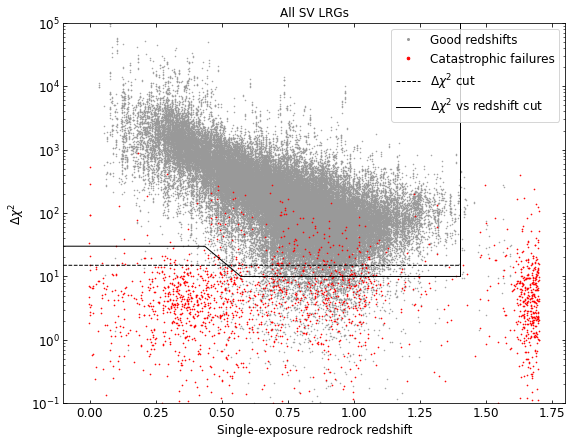

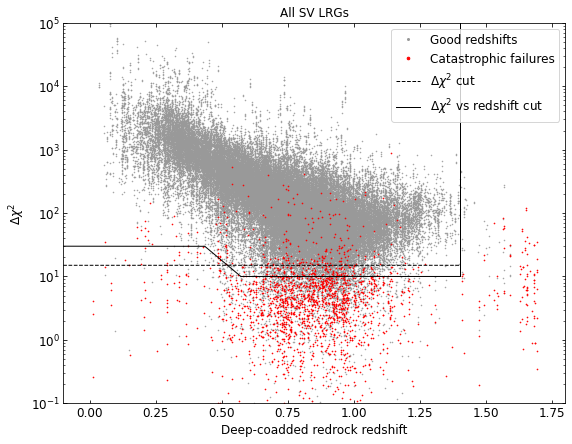

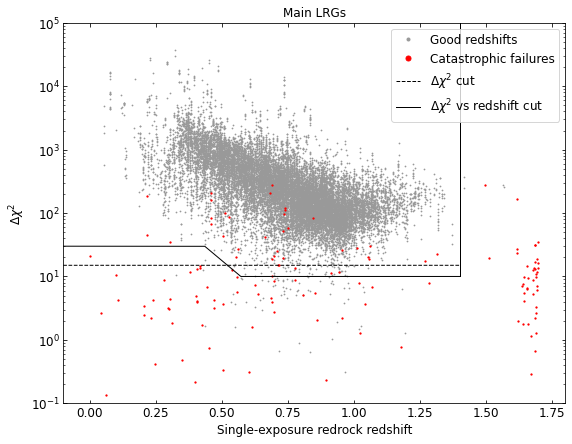

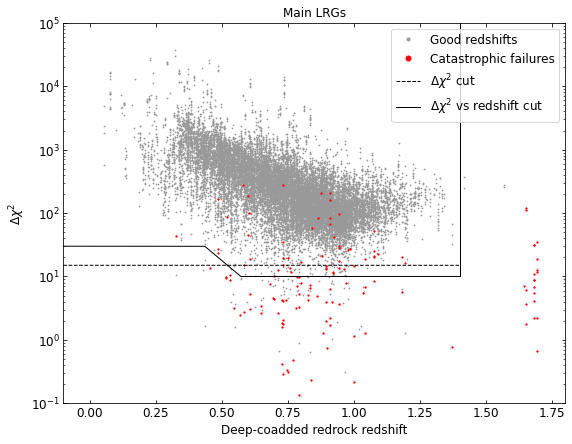

In [19]:
x = np.linspace(-1, 1.4, 10000)
y = np.ones_like(x)
y = (10**(3 - 3.5*x))
y[y<10] = 10
y[y>30] = 30
y1 = np.linspace(10, 1e6)
x1 = np.ones_like(y1) * 1.4
x0 = np.linspace(-1, 1.4, 10000)
y0 = 15 * np.ones_like(x0)

mask = np.full(len(cat), True)
plt.figure(figsize=(9, 7))
plt.plot(cat['Z'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=1, alpha=1, label='Good redshifts', zorder=1)
plt.plot(cat['Z'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'r.', ms=1.3, alpha=1, label='Catastrophic failures', zorder=2)
plt.plot(x0, y0, color='k', lw=1, ls='--', label='$\Delta \chi^2$ cut')
plt.plot(x, y, color='k', lw=1, label='$\Delta \chi^2$ vs redshift cut')
plt.plot(x1, y1, color='k', lw=1)
plt.yscale('log')
plt.xlabel('Single-exposure redrock redshift')
plt.ylabel('$\Delta \chi^2$')
plt.axis([-0.1, 1.8, .1, 100000])
plt.legend(markerscale=4, loc='upper right')
# plt.grid(alpha=0.5)
plt.title('All SV LRGs')
plt.show()

mask = np.full(len(cat), True)
plt.figure(figsize=(9, 7))
plt.plot(cat['Z_deep'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=1, alpha=1, label='Good redshifts', zorder=1)
plt.plot(cat['Z_deep'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'r.', ms=1.3, alpha=1, label='Catastrophic failures', zorder=2)
plt.plot(x0, y0, color='k', lw=1, ls='--', label='$\Delta \chi^2$ cut')
plt.plot(x, y, color='k', lw=1, label='$\Delta \chi^2$ vs redshift cut')
plt.plot(x1, y1, color='k', lw=1)
plt.yscale('log')
plt.xlabel('Deep-coadded redrock redshift')
plt.ylabel('$\Delta \chi^2$')
plt.axis([-0.1, 1.8, .1, 100000])
plt.legend(markerscale=4, loc='upper right')
# plt.grid(alpha=0.5)
plt.title('All SV LRGs')
plt.show()

mask = cat['main_lrg'].copy()
plt.figure(figsize=(9, 7))
plt.plot(cat['Z'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=1.5, alpha=1, label='Good redshifts', zorder=1)
plt.plot(cat['Z'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'r.', ms=2.5, alpha=1, label='Catastrophic failures', zorder=2)
plt.plot(x0, y0, color='k', lw=1, ls='--', label='$\Delta \chi^2$ cut')
plt.plot(x, y, color='k', lw=1, label='$\Delta \chi^2$ vs redshift cut')
plt.plot(x1, y1, color='k', lw=1)
plt.yscale('log')
plt.xlabel('Single-exposure redrock redshift')
plt.ylabel('$\Delta \chi^2$')
plt.axis([-0.1, 1.8, .1, 100000])
plt.legend(markerscale=4, loc='upper right')
# plt.grid(alpha=0.5)
plt.title('Main LRGs')
plt.show()

mask = cat['main_lrg'].copy()
plt.figure(figsize=(9, 7))
plt.plot(cat['Z_deep'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=1.5, alpha=1, label='Good redshifts', zorder=1)
plt.plot(cat['Z_deep'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'r.', ms=2.5, alpha=1, label='Catastrophic failures', zorder=2)
plt.plot(x0, y0, color='k', lw=1, ls='--', label='$\Delta \chi^2$ cut')
plt.plot(x, y, color='k', lw=1, label='$\Delta \chi^2$ vs redshift cut')
plt.plot(x1, y1, color='k', lw=1)
plt.yscale('log')
plt.xlabel('Deep-coadded redrock redshift')
plt.ylabel('$\Delta \chi^2$')
plt.axis([-0.1, 1.8, .1, 100000])
plt.legend(markerscale=4, loc='upper right')
# plt.grid(alpha=0.5)
plt.title('Main LRGs')
plt.show()

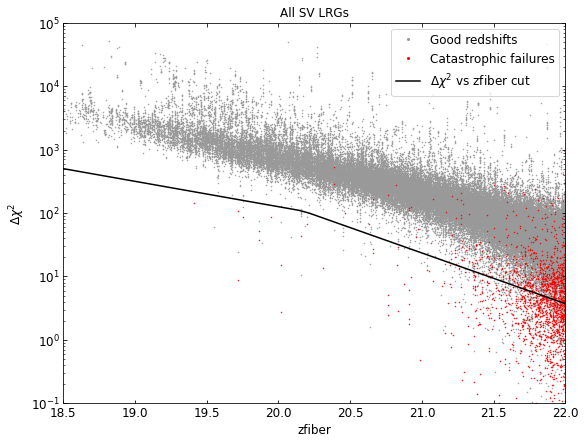

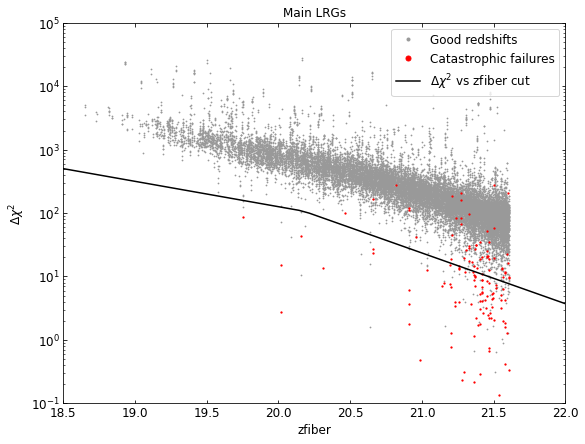

In [20]:
x = np.linspace(18.5, 22)
y1 = 10**(-(x-20)*0.4*2 + 2.17)  # sky dominated
y2 = 10**(-(x-20)*0.4 + 2.1)  # source dominated
y = np.minimum(y1, y2)

mask = np.full(len(cat), True)
plt.figure(figsize=(9, 7))
plt.plot(cat['zfibermag'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=1, alpha=1, label='Good redshifts', zorder=1)
plt.plot(cat['zfibermag'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'r.', ms=1, alpha=1, label='Catastrophic failures', zorder=2)
plt.plot(x, y, color='k', label='$\Delta \chi^2$ vs zfiber cut')
plt.yscale('log')
plt.xlabel('zfiber')
plt.ylabel('$\Delta \chi^2$')
plt.axis([18.5, 22., .1, 100000])
plt.legend(markerscale=4, loc='upper right')
# plt.grid(alpha=0.5)
plt.title('All SV LRGs')
plt.show()

mask = cat['main_lrg'].copy()
plt.figure(figsize=(9, 7))
plt.plot(cat['zfibermag'][mask & (~mask_fail)], cat['DELTACHI2'][mask & (~mask_fail)], '.', color='0.6', ms=1.5, alpha=1, label='Good redshifts', zorder=1)
plt.plot(cat['zfibermag'][mask & mask_fail], cat['DELTACHI2'][mask & mask_fail], 'r.', ms=2.5, alpha=1, label='Catastrophic failures', zorder=2)
plt.plot(x, y, color='k', label='$\Delta \chi^2$ vs zfiber cut')
plt.yscale('log')
plt.xlabel('zfiber')
plt.ylabel('$\Delta \chi^2$')
plt.axis([18.5, 22., .1, 100000])
plt.legend(markerscale=4, loc='upper right')
# plt.grid(alpha=0.5)
plt.title('Main LRGs')
plt.show()

Try a few different DELTACHI2 thresholds

In [21]:
# DELTACHI2 cut
q0 = cat['ZWARN']==0
q0 &= (cat['Z']<1.5)
q0 &= cat['DELTACHI2']>10

# DELTACHI2 cut
mq0 = main['ZWARN']==0
mq0 &= main['Z']<1.5
mq0 &= main['DELTACHI2']>10

print('SV LRGs:')
print('Removed fraction: {:.2f}%'.format(100*np.sum(~q0)/len(q0)))
print('Catastrophic failure rate of removed objects: {:.2f}% ({}/{})'.format(100*np.sum((~q0) & mask_fail)/np.sum(~q0), np.sum((~q0) & mask_fail), np.sum(~q0)))
print('Catastrophic failure rate of remaining objects: {:.2f}% ({}/{})'.format(100*np.sum((q0) & mask_fail)/np.sum(q0), np.sum(q0 & mask_fail), np.sum(q0)))
print()

mask = cat['main_lrg'].copy()
print('Main LRGs in SV:')
print('Removed fraction: {:.2f}%'.format(100*np.sum(mask & (~q0))/np.sum(mask)))
print('Catastrophic failure rate of removed objects: {:.2f}% ({}/{})'.format(100*np.sum(mask & (~q0) & mask_fail)/np.sum(mask & (~q0)), np.sum(mask & (~q0) & mask_fail), np.sum(mask & (~q0))))
print('Catastrophic failure rate of remaining objects: {:.2f}% ({}/{})'.format(100*np.sum(mask & q0 & mask_fail)/np.sum(mask & q0), np.sum(mask & q0 & mask_fail), np.sum(mask & q0)))
print()

print('Main LRGs in Main Survey:')
print('Removed fraction: {:.2f}% ({}/{})'.format(100*np.sum(~mq0)/len(mq0), np.sum(~mq0), len(mq0)))
print()

SV LRGs:
Removed fraction: 4.88%
Catastrophic failure rate of removed objects: 47.98% (1531/3191)
Catastrophic failure rate of remaining objects: 0.57% (355/62241)

Main LRGs in SV:
Removed fraction: 0.83%
Catastrophic failure rate of removed objects: 57.52% (88/153)
Catastrophic failure rate of remaining objects: 0.25% (46/18178)

Main LRGs in Main Survey:
Removed fraction: 0.94% (2697/286892)



In [22]:
# DELTACHI2 cut
q0 = cat['ZWARN']==0
q0 &= (cat['Z']<1.5)
q0 &= cat['DELTACHI2']>15

# DELTACHI2 cut
mq0 = main['ZWARN']==0
mq0 &= main['Z']<1.5
mq0 &= main['DELTACHI2']>15

print('SV LRGs:')
print('Removed fraction: {:.2f}%'.format(100*np.sum(~q0)/len(q0)))
print('Catastrophic failure rate of removed objects: {:.2f}% ({}/{})'.format(100*np.sum((~q0) & mask_fail)/np.sum(~q0), np.sum((~q0) & mask_fail), np.sum(~q0)))
print('Catastrophic failure rate of remaining objects: {:.2f}% ({}/{})'.format(100*np.sum((q0) & mask_fail)/np.sum(q0), np.sum(q0 & mask_fail), np.sum(q0)))
print()

mask = cat['main_lrg'].copy()
print('Main LRGs in SV:')
print('Removed fraction: {:.2f}%'.format(100*np.sum(mask & (~q0))/np.sum(mask)))
print('Catastrophic failure rate of removed objects: {:.2f}% ({}/{})'.format(100*np.sum(mask & (~q0) & mask_fail)/np.sum(mask & (~q0)), np.sum(mask & (~q0) & mask_fail), np.sum(mask & (~q0))))
print('Catastrophic failure rate of remaining objects: {:.2f}% ({}/{})'.format(100*np.sum(mask & q0 & mask_fail)/np.sum(mask & q0), np.sum(mask & q0 & mask_fail), np.sum(mask & q0)))
print()

print('Main LRGs in Main Survey:')
print('Removed fraction: {:.2f}% ({}/{})'.format(100*np.sum(~mq0)/len(mq0), np.sum(~mq0), len(mq0)))
print()

SV LRGs:
Removed fraction: 6.79%
Catastrophic failure rate of removed objects: 37.48% (1666/4445)
Catastrophic failure rate of remaining objects: 0.36% (220/60987)

Main LRGs in SV:
Removed fraction: 1.18%
Catastrophic failure rate of removed objects: 45.37% (98/216)
Catastrophic failure rate of remaining objects: 0.20% (36/18115)

Main LRGs in Main Survey:
Removed fraction: 1.23% (3532/286892)



__Objects with 10<DELTACHI2<15__

In [23]:
# DELTACHI2 cut
q0 = cat['ZWARN']==0
q0 &= (cat['Z']<1.5)
q0 &= (cat['DELTACHI2']>10) & (cat['DELTACHI2']<15)

# DELTACHI2 cut
mq0 = main['ZWARN']==0
mq0 &= main['Z']<1.5
mq0 &= (main['DELTACHI2']>10) & (main['DELTACHI2']<15)

print('SV LRGs:')
print('Fraction: {:.2f}%'.format(100*np.sum(q0)/len(q0)))
print('Catastrophic failure rate of remaining objects: {:.2f}% ({}/{})'.format(100*np.sum((q0) & mask_fail)/np.sum(q0), np.sum(q0 & mask_fail), np.sum(q0)))
print()

mask = cat['main_lrg'].copy()
print('Main LRGs in SV:')
print('Fraction: {:.2f}%'.format(100*np.sum(mask & (q0))/np.sum(mask)))
print('Catastrophic failure rate of remaining objects: {:.2f}% ({}/{})'.format(100*np.sum(mask & q0 & mask_fail)/np.sum(mask & q0), np.sum(mask & q0 & mask_fail), np.sum(mask & q0)))
print()

print('Main LRGs in Main Survey:')
print('Fraction: {:.2f}% ({}/{})'.format(100*np.sum(mq0)/len(mq0), np.sum(mq0), len(mq0)))
print()

SV LRGs:
Fraction: 1.92%
Catastrophic failure rate of remaining objects: 10.77% (135/1254)

Main LRGs in SV:
Fraction: 0.34%
Catastrophic failure rate of remaining objects: 15.87% (10/63)

Main LRGs in Main Survey:
Fraction: 0.29% (835/286892)



__Objects with 15<DELTACHI2<20__

In [24]:
# DELTACHI2 cut
q0 = cat['ZWARN']==0
q0 &= (cat['Z']<1.5)
q0 &= (cat['DELTACHI2']>15) & (cat['DELTACHI2']<20)

# DELTACHI2 cut
mq0 = main['ZWARN']==0
mq0 &= main['Z']<1.5
mq0 &= (main['DELTACHI2']>15) & (main['DELTACHI2']<20)

print('SV LRGs:')
print('Fraction: {:.2f}%'.format(100*np.sum(q0)/len(q0)))
print('Catastrophic failure rate of remaining objects: {:.2f}% ({}/{})'.format(100*np.sum((q0) & mask_fail)/np.sum(q0), np.sum(q0 & mask_fail), np.sum(q0)))
print()

mask = cat['main_lrg'].copy()
print('Main LRGs in SV:')
print('Fraction: {:.2f}%'.format(100*np.sum(mask & (q0))/np.sum(mask)))
print('Catastrophic failure rate of remaining objects: {:.2f}% ({}/{})'.format(100*np.sum(mask & q0 & mask_fail)/np.sum(mask & q0), np.sum(mask & q0 & mask_fail), np.sum(mask & q0)))
print()

print('Main LRGs in Main Survey:')
print('Fraction: {:.2f}% ({}/{})'.format(100*np.sum(mq0)/len(mq0), np.sum(mq0), len(mq0)))
print()

SV LRGs:
Fraction: 2.13%
Catastrophic failure rate of remaining objects: 3.88% (54/1392)

Main LRGs in SV:
Fraction: 0.39%
Catastrophic failure rate of remaining objects: 8.45% (6/71)

Main LRGs in Main Survey:
Fraction: 0.33% (956/286892)



__Objects with 1.4<Z<1.5__

In [25]:
# DELTACHI2 cut
q0 = cat['ZWARN']==0
q0 &= (cat['Z']>1.4) & (cat['Z']<1.5)
q0 &= (cat['DELTACHI2']>15)

# DELTACHI2 cut
mq0 = main['ZWARN']==0
mq0 &= (main['Z']>1.4) & (main['Z']<1.5)
mq0 &= (main['DELTACHI2']>15)

print('SV LRGs:')
print('Fraction: {:.2f}%'.format(100*np.sum(q0)/len(q0)))
print('Catastrophic failure rate of remaining objects: {:.2f}% ({}/{})'.format(100*np.sum((q0) & mask_fail)/np.sum(q0), np.sum(q0 & mask_fail), np.sum(q0)))
print()

mask = cat['main_lrg'].copy()
print('Main LRGs in SV:')
print('Fraction: {:.2f}%'.format(100*np.sum(mask & (q0))/np.sum(mask)))
print('Catastrophic failure rate of remaining objects: {:.2f}% ({}/{})'.format(100*np.sum(mask & q0 & mask_fail)/np.sum(mask & q0), np.sum(mask & q0 & mask_fail), np.sum(mask & q0)))
print()

print('Main LRGs in Main Survey:')
print('Fraction: {:.2f}% ({}/{})'.format(100*np.sum(mq0)/len(mq0), np.sum(mq0), len(mq0)))
print()

SV LRGs:
Fraction: 0.06%
Catastrophic failure rate of remaining objects: 16.67% (6/36)

Main LRGs in SV:
Fraction: 0.02%
Catastrophic failure rate of remaining objects: 33.33% (1/3)

Main LRGs in Main Survey:
Fraction: 0.03% (81/286892)

